In [1]:
from collections import defaultdict

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files
    DATA_PATH = list(files.upload())[0]
except ImportError:
    DATA_PATH = "trade-register.csv"

Saving trade-register.csv to trade-register.csv


In [2]:
# ---- load, clean, build annual edges --------------------------------------
with open(DATA_PATH, encoding="latin-1") as fh:
    header = next(i for i, line in enumerate(fh) if "Recipient,Supplier" in line)

raw = pd.read_csv(DATA_PATH, skiprows=header, encoding="latin-1", low_memory=False)
raw.columns = raw.columns.str.strip()

data = raw.dropna(subset=["Recipient", "Supplier"]).copy()
for col in ["Recipient", "Supplier"]:
    data[col] = data[col].astype(str).str.strip()
    data = data[~data[col].str.endswith("*")].copy()
    data = data[~data[col].str.contains("unknown", case=False)].copy()
data = data[data["Recipient"] != data["Supplier"]].copy()

order_year = pd.to_numeric(data["Year of order"], errors="coerce")
tiv = pd.to_numeric(data["SIPRI TIV for total order"], errors="coerce")

weights = defaultdict(float)
for supplier, recipient, year, value in zip(data["Supplier"], data["Recipient"],
                                            order_year, tiv):
    if pd.isna(year) or pd.isna(value) or value < 0:
        continue
    year = int(year)
    if not 1950 <= year <= 2024:
        continue
    value = 0.25 if value == 0 else float(value)
    if year < 1992:
        supplier = "Soviet Union" if supplier == "Russia" else supplier
        recipient = "Soviet Union" if recipient == "Russia" else recipient
    if supplier != recipient:
        weights[(supplier, recipient, year)] += value

edges = pd.DataFrame([(s, r, y, w) for (s, r, y), w in weights.items()],
                     columns=["supplier", "recipient", "year", "weight"])
print(f"{len(edges):,} annual dyad edges, "
      f"{len(set(edges.supplier) | set(edges.recipient))} countries, "
      f"{edges.year.min()}-{edges.year.max()}")

15,264 annual dyad edges, 195 countries, 1950-2024


In [4]:
# ---- 1. Assign each recipient to its dominant supplier --------------------
# dependence = share of that year's imports coming from the largest supplier.
# A value near 1 means the recipient is a single-supplier client.

totals = edges.groupby(["recipient", "year"])["weight"].sum().rename("total_imports")
ranked = (edges.sort_values("weight", ascending=False)
          .drop_duplicates(["recipient", "year"])
          .merge(totals, on=["recipient", "year"]))
ranked["dependence"] = ranked["weight"] / ranked["total_imports"]
clients = ranked.rename(columns={"supplier": "main_supplier"})[
    ["recipient", "year", "main_supplier", "dependence", "total_imports"]]
clients.to_csv("client_assignment.csv", index=False)

In [5]:
# ---- 2. How large is each supplier's clientele, year by year? -------------
clientele = (clients.groupby(["year", "main_supplier"])
             .agg(clients=("recipient", "size"),
                  mean_dependence=("dependence", "mean"))
             .reset_index())
clientele.to_csv("clientele_size.csv", index=False)

In [6]:

# ---- 3. Concentration: how much of the market do the top suppliers hold? --
per_year = []
for year, group in edges.groupby("year"):
    by_supplier = group.groupby("supplier")["weight"].sum().sort_values(ascending=False)
    n_recipients = group["recipient"].nunique()
    graph = nx.DiGraph()
    for e in group.itertuples(index=False):
        graph.add_edge(e.supplier, e.recipient)
    per_year.append({
        "year": year,
        "recipients": n_recipients,
        "suppliers": len(by_supplier),
        "top1_tiv_share": by_supplier.iloc[0] / by_supplier.sum(),
        "top3_tiv_share": by_supplier.head(3).sum() / by_supplier.sum(),
        "mean_dependence": clients[clients.year == year]["dependence"].mean(),
        "single_supplier_clients": (
            clients[(clients.year == year) & (clients.dependence == 1.0)].shape[0]
            / max(n_recipients, 1)),
        "out_in_assortativity": nx.degree_assortativity_coefficient(
            graph, x="out", y="in"),
    })
concentration = pd.DataFrame(per_year)
concentration.to_csv("concentration_over_time.csv", index=False)

MAJOR = ["United States", "Soviet Union", "Russia", "France",
         "United Kingdom", "China", "Germany"]

print("\nClientele size in benchmark years (recipients whose largest supplier this was)")
print(clientele[clientele.year.isin([1964, 1984, 1999, 2024])
                & clientele.main_supplier.isin(MAJOR)]
      .pivot(index="main_supplier", columns="year", values="clients")
      .fillna(0).astype(int).to_string())

print("\nMarket concentration, benchmark years")
print(concentration[concentration.year.isin([1964, 1984, 1999, 2024])]
      .round(3).to_string(index=False))


Clientele size in benchmark years (recipients whose largest supplier this was)
year            1964  1984  1999  2024
main_supplier                         
China              1     2     3     5
France            15    20     8     6
Germany            2     4    11     7
Russia             0     0    10     4
Soviet Union      21    26     0     0
United Kingdom    14    10     9     1
United States     32    34    22    32

Market concentration, benchmark years
 year  recipients  suppliers  top1_tiv_share  top3_tiv_share  mean_dependence  single_supplier_clients  out_in_assortativity
 1964          92         22           0.498           0.897            0.919                    0.565                -0.197
 1984         112         36           0.396           0.834            0.883                    0.518                -0.240
 1999          99         38           0.288           0.633            0.833                    0.485                -0.091
 2024         103         45  

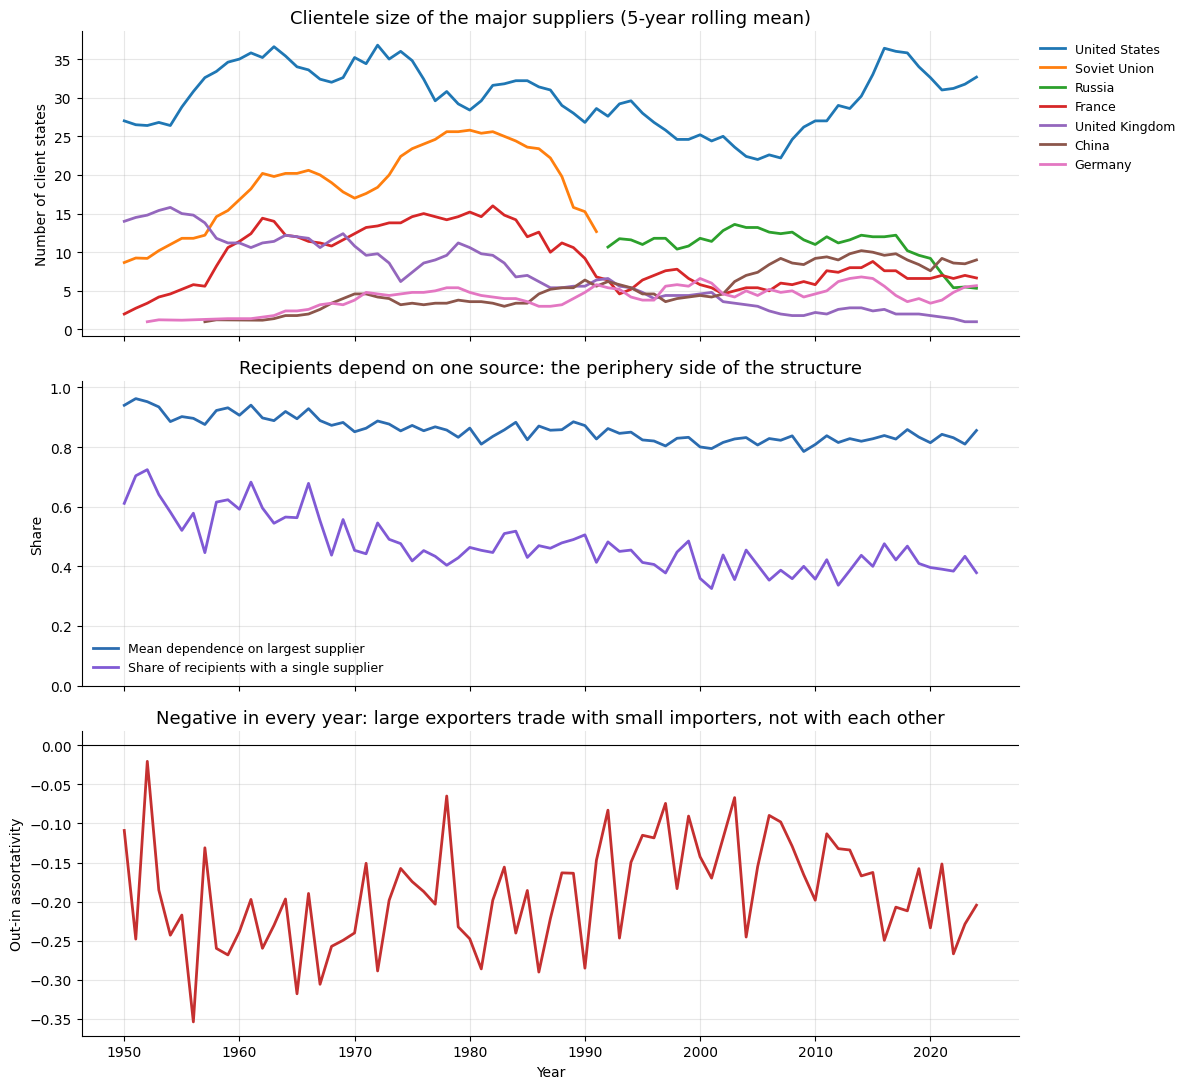

In [7]:
# ---- 4. Figure -----------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for supplier in MAJOR:
    series = clientele[clientele.main_supplier == supplier]
    if len(series) > 5:
        axes[0].plot(series["year"],
                     series["clients"].rolling(5, center=True, min_periods=1).mean(),
                     lw=2, label=supplier)
axes[0].set_ylabel("Number of client states")
axes[0].set_title("Clientele size of the major suppliers (5-year rolling mean)",
                  fontsize=13)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)

axes[1].plot(concentration["year"], concentration["mean_dependence"],
             color="#2b6cb0", lw=2, label="Mean dependence on largest supplier")
axes[1].plot(concentration["year"], concentration["single_supplier_clients"],
             color="#805ad5", lw=2, label="Share of recipients with a single supplier")
axes[1].set_ylabel("Share")
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Recipients depend on one source: the periphery side of the structure",
                  fontsize=13)
axes[1].legend(frameon=False, fontsize=9)

axes[2].axhline(0, color="black", lw=0.8)
axes[2].plot(concentration["year"], concentration["out_in_assortativity"],
             color="#c53030", lw=2)
axes[2].set_ylabel("Out-in assortativity")
axes[2].set_xlabel("Year")
axes[2].set_title("Negative in every year: large exporters trade with small "
                  "importers, not with each other", fontsize=13)

for ax in axes:
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("supplier_structure.pdf", bbox_inches="tight")
plt.show()